In [1]:
# Крок 1. Імпорти та налаштування графіків

import re
from collections import Counter

import spacy
from spacy import displacy
from spacy.matcher import Matcher
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (8, 3.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.linewidth"] = 0.3
plt.rcParams["grid.alpha"] = 0.5
plt.rcParams["font.size"] = 9

In [2]:
# Крок 2. Беремо готову модель української мови і дивимось, з чого вона складається

nlp = spacy.load("uk_core_news_md")

print("версія spacy:", spacy.__version__)
print("кроки пайплайну:", nlp.pipe_names)
print("мітки ner:", nlp.get_pipe("ner").labels)
print("матриця векторів:", nlp.vocab.vectors.shape)

# міток лише три: місця, організації та люди
# дат і грошових сум серед них немає, це знадобиться далі

версія spacy: 3.8.15
кроки пайплайну: ['tok2vec', 'morphologizer', 'parser', 'attribute_ruler', 'lemmatizer', 'ner']
мітки ner: ('LOC', 'ORG', 'PER')
матриця векторів: (50000, 300)


In [3]:
# Крок 3. Текст, з яким працюємо

text = """
Ігор Сікорський народився в Києві 1889 року і навчався в Київському політехнічному інституті.
Уже 1913 року він підняв у повітря "Російський витязь" — перший у світі чотиримоторний літак.
Наступного року Сікорський побудував важкий бомбардувальник "Ілля Муромець".
Після 1919 року конструктор виїхав до США і заснував компанію Sikorsky Aircraft.
Саме там 1939 року він створив вертоліт VS-300, який визначив вигляд усієї галузі.
Сергій Корольов народився в Житомирі 1907 року.
Під його керівництвом Радянський Союз запустив перший штучний супутник Землі в жовтні 1957 року.
12 квітня 1961 року Юрій Гагарін здійснив перший політ людини в космос.
Ім'я Корольова тривалий час залишалося таємницею, і газети називали його "Головний конструктор".
Юрій Кондратюк, справжнє ім'я якого Олександр Шаргей, народився в Полтаві 1897 року.
Ще 1929 року він видав у Новосибірську книжку "Завоювання міжпланетних просторів".
У ній Кондратюк описав схему польоту на Місяць через орбітальне рандеву.
Інженери NASA використали цю ідею в програмі "Аполлон".
Леонід Каденюк став першим космонавтом незалежної України.
У листопаді 1997 року він вирушив на орбіту на шатлі "Колумбія" разом з екіпажем NASA.
Каденюк проводив біологічні експерименти з рослинами разом з Інститутом ботаніки в Києві.
Сьогодні ракети стартують з космодрому Байконур у Казахстані та з мису Канаверал у Флориді.
Компанія SpaceX зробила багаторазовість нормою: перший ступінь Falcon 9 повертається на платформу.
Європейське космічне агентство координує роботу з Парижа.
NASA планує повернути людей на Місяць у межах програми "Артеміда".
Один запуск важкої ракети коштує сотні мільйонів доларів, а місячний проєкт оцінюють
у понад 90 мільярдів доларів.
Українські підприємства, зокрема "Південмаш" у Дніпрі, десятиліттями виготовляли ракети-носії.
""".strip()

print("символів:", len(text))
print(text[:200], "...")

символів: 1801
Ігор Сікорський народився в Києві 1889 року і навчався в Київському політехнічному інституті.
Уже 1913 року він підняв у повітря "Російський витязь" — перший у світі чотиримоторний літак.
Наступного р ...


In [4]:
# Крок 4. Загальний огляд тексту

doc = nlp(text)
sents = list(doc.sents)
words = [t for t in doc if not t.is_punct and not t.is_space]

print("речень:", len(sents))
print("токенів усього:", len(doc))
print("слів без пунктуації:", len(words))
print("унікальних лем:", len({t.lemma_ for t in words}))

речень: 22
токенів усього: 321
слів без пунктуації: 251
унікальних лем: 181


In [5]:
# Крок 4. Дивимось, що модель дає для кожного токена

rows = [(t.text, t.lemma_, t.pos_, t.is_stop) for t in doc[:12]]
pd.DataFrame(rows, columns=["токен", "лема", "частина_мови", "стоп_слово"])

# леми власних назв виходять з малої літери, а Києві зводиться до кий

,токен,лема,частина_мови,стоп_слово
0,Ігор,ігор,PROPN,False
1,Сікорський,сікорський,PROPN,False
2,народився,народитися,VERB,False
3,в,в,ADP,True
4,Києві,кий,PROPN,False
5,1889,1889,ADJ,False
6,року,рок,NOUN,True
7,і,і,CCONJ,True
8,навчався,навчатися,VERB,False
9,в,в,ADP,True


In [6]:
# Крок 5. Іменовані сутності, які знайшла модель

ent_rows = [(e.text, e.start_char, e.end_char, e.label_) for e in doc.ents]
ents_df = pd.DataFrame(ent_rows, columns=["текст", "початок", "кінець", "мітка"])

print("знайдено сутностей:", len(ents_df))
ents_df.head(25)

знайдено сутностей: 41


,текст,початок,кінець,мітка
0,Ігор Сікорський,0,15,PER
1,Києві,28,33,LOC
2,Київському політехнічному інституті,57,92,ORG
3,Сікорський,204,214,PER
4,Ілля Муромець,249,262,PER
5,США,303,306,LOC
6,Sikorsky Aircraft,327,344,ORG
7,VS-300,386,392,ORG
8,Сергій Корольов,429,444,PER
9,Житомирі,457,465,LOC


{'PER': 11, 'LOC': 17, 'ORG': 13}


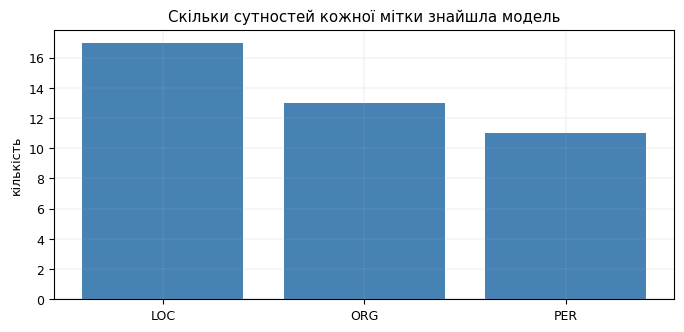

In [7]:
# Крок 6. Розподіл сутностей по мітках

counts = Counter(e.label_ for e in doc.ents)
print(dict(counts))

order = sorted(counts, key=counts.get, reverse=True)
plt.bar(order, [counts[label] for label in order], color="steelblue")
plt.title("Скільки сутностей кожної мітки знайшла модель")
plt.ylabel("кількість")
plt.show()

In [8]:
# Крок 6. Які саме сутності потрапили в кожну мітку

for label in sorted(counts):
    uniq = sorted({e.text for e in doc.ents if e.label_ == label})
    print(label, "(" + str(len(uniq)) + "):", ", ".join(uniq))

LOC (15): Байконур, Дніпрі, Житомирі, Землі, Казахстані, Канаверал, Києві, Місяць, Новосибірську, Парижа, Полтаві, Радянський Союз, США, України, Флориді
ORG (11): NASA, Sikorsky Aircraft, SpaceX, VS-300, Європейське космічне агентство, Інститутом ботаніки, Аполлон, Артеміда, Київському політехнічному інституті, Колумбія, Південмаш
PER (11): Ігор Сікорський, Ілля Муромець, Каденюк, Кондратюк, Корольова, Леонід Каденюк, Олександр Шаргей, Сергій Корольов, Сікорський, Юрій Гагарін, Юрій Кондратюк


In [9]:
# Крок 7. Якщо потрібні лише сутності, зайві кроки пайплайну можна вимкнути

off = ["morphologizer", "parser", "attribute_ruler", "lemmatizer"]
with nlp.select_pipes(disable=off):
    light_doc = nlp(text)

print("сутностей у повному пайплайні:", len(doc.ents))
print("сутностей із вимкненими кроками:", len(light_doc.ents))
print("списки збігаються:", [e.text for e in doc.ents] == [e.text for e in light_doc.ents])

# набір сутностей не змінився, тобто на пошук сутностей ці кроки не вплинули

сутностей у повному пайплайні: 41
сутностей із вимкненими кроками: 41
списки збігаються: True


In [10]:
# Крок 8. Візуалізація сутностей прямо в тексті

displacy.render(doc, style="ent", jupyter=True)

In [11]:
# Крок 9. Перевіряємо на конкретних прикладах, що модель знайшла, а що ні

check = [
    ("Ігор Сікорський", "PER"), ("Сергій Корольов", "PER"), ("Юрій Гагарін", "PER"),
    ("Юрій Кондратюк", "PER"), ("Олександр Шаргей", "PER"), ("Леонід Каденюк", "PER"),
    ("Sikorsky Aircraft", "ORG"), ("NASA", "ORG"), ("SpaceX", "ORG"), ("Південмаш", "ORG"),
    ("Києві", "LOC"), ("Житомирі", "LOC"), ("Полтаві", "LOC"), ("Байконур", "LOC"),
]

found = {e.text: e.label_ for e in doc.ents}
rows = []
for name, want in check:
    got = found.get(name, "не знайдено")
    rows.append((name, want, got, "так" if got == want else "ні"))

pd.DataFrame(rows, columns=["сутність", "очікуємо", "модель дала", "збіг"])

,сутність,очікуємо,модель дала,збіг
0,Ігор Сікорський,PER,PER,так
1,Сергій Корольов,PER,PER,так
2,Юрій Гагарін,PER,PER,так
3,Юрій Кондратюк,PER,PER,так
4,Олександр Шаргей,PER,PER,так
5,Леонід Каденюк,PER,PER,так
6,Sikorsky Aircraft,ORG,ORG,так
7,NASA,ORG,ORG,так
8,SpaceX,ORG,ORG,так
9,Південмаш,ORG,ORG,так


In [12]:
# Крок 9. Дивимось на довгі сутності та на назви, взяті в лапки

long_ents = [e.text for e in doc.ents if len(e.text.split()) > 2]
print("сутності довші за два слова:", long_ents)

quoted = re.findall(r'"([^"]+)"', text)
print("назви в лапках у тексті:", quoted)
print("з них розпізнані як сутності:", [q for q in quoted if q in found])

сутності довші за два слова: ['Київському політехнічному інституті', 'Європейське космічне агентство']
назви в лапках у тексті: ['Російський витязь', 'Ілля Муромець', 'Головний конструктор', 'Завоювання міжпланетних просторів', 'Аполлон', 'Колумбія', 'Артеміда', 'Південмаш']
з них розпізнані як сутності: ['Ілля Муромець', 'Аполлон', 'Колумбія', 'Артеміда', 'Південмаш']


In [13]:
# Крок 9. Тепер дивимось, де модель помилилась

suspect = ["VS-300", "Ілля Муромець", "Колумбія", "Аполлон", "Артеміда", "Радянський Союз"]
for name in suspect:
    got = [e.label_ for e in doc.ents if e.text == name]
    print(name, "->", got[0] if got else "не знайдено")

print()
print("зовсім не знайдено:", [n for n in ("Falcon 9", "Російський витязь") if n not in found])

# назви техніки частіше йдуть в організації, а "Ілля Муромець" модель віднесла до людей

VS-300 -> ORG
Ілля Муромець -> PER
Колумбія -> ORG
Аполлон -> ORG
Артеміда -> ORG
Радянський Союз -> LOC

зовсім не знайдено: ['Falcon 9', 'Російський витязь']


In [14]:
# Крок 10. Дати і суми модель не розмічає, бо таких міток у неї немає

years = sorted(set(re.findall(r"\b1\d{3}\b|\b20\d{2}\b", text)))
print("років згадано в тексті:", len(years), "->", years)

# перевіряємо не лише те, що окремої мітки немає, а й чи не потрапив рік усередину сутності
in_ents = [y for y in years if any(y in e.text for e in doc.ents)]
print("років, що потрапили в якусь сутність:", in_ents)
print("сум, що потрапили в якусь сутність:", [e.text for e in doc.ents if "доларів" in e.text])

років згадано в тексті: 10 -> ['1889', '1897', '1907', '1913', '1919', '1929', '1939', '1957', '1961', '1997']
років, що потрапили в якусь сутність: []
сум, що потрапили в якусь сутність: []


In [15]:
# Крок 11. Перевіряємо, чи впливає регістр на розпізнавання

probe = "Компанія SpaceX запустила ракету з Флориди разом з інженерами NASA."
for variant in (probe, probe.lower()):
    found_here = [(e.text, e.label_) for e in nlp(variant).ents]
    print(variant)
    print("   ->", found_here)

# на цьому реченні різниці немає, але одного прикладу мало щоб робити висновок

Компанія SpaceX запустила ракету з Флориди разом з інженерами NASA.
   -> [('SpaceX', 'ORG'), ('Флориди', 'LOC'), ('NASA', 'ORG')]
компанія spacex запустила ракету з флориди разом з інженерами nasa.
   -> [('spacex', 'ORG'), ('флориди', 'LOC'), ('nasa', 'ORG')]


In [16]:
# Крок 11. Та сама перевірка, але вже на всьому тексті

lower_doc = nlp(text.lower())
print("сутностей в оригіналі:", len(doc.ents))
print("сутностей у нижньому регістрі:", len(lower_doc.ents))

was = {(e.text.lower(), e.label_) for e in doc.ents}
now = {(e.text, e.label_) for e in lower_doc.ents}

print()
print("загубилось:", sorted(t for t, _ in was - now))
print("додалось зайвого:", sorted(t for t, _ in now - was))

# на довшому тексті регістр уже впливає, частина назв зникає

сутностей в оригіналі: 41
сутностей у нижньому регістрі: 33

загубилось: ['байконур', 'землі', 'колумбія', 'кондратюк', 'місяць', 'новосибірську', 'радянський союз', 'ілля муромець']
додалось зайвого: ['шатлі "']


In [17]:
# Крок 12. Порівнюємо три моделі на тому самому тексті

model_names = ["uk_core_news_sm", "uk_core_news_md", "uk_core_news_lg"]
docs_by_model = {name: spacy.load(name)(text) for name in model_names}

summary = []
for name, model_doc in docs_by_model.items():
    per_label = [sum(1 for e in model_doc.ents if e.label_ == label)
                 for label in ("PER", "ORG", "LOC")]
    summary.append([name, len(model_doc.ents)] + per_label)

pd.DataFrame(summary, columns=["модель", "усього", "PER", "ORG", "LOC"])

,модель,усього,PER,ORG,LOC
0,uk_core_news_sm,39,10,11,18
1,uk_core_news_md,41,11,13,17
2,uk_core_news_lg,40,11,12,17


In [18]:
# Крок 12. Дивимось, у чому саме моделі розходяться

sets = {name: {(e.text, e.label_) for e in model_doc.ents}
        for name, model_doc in docs_by_model.items()}
sm, lg = sets["uk_core_news_sm"], sets["uk_core_news_lg"]

print("є у великій, немає в малій:", sorted(lg - sm))
print()
print("є в малій, немає у великій:", sorted(sm - lg))

є у великій, немає в малій: [('Каденюк', 'PER'), ('Колумбія', 'ORG')]

є в малій, немає у великій: [('Колумбія', 'LOC')]


In [19]:
# Крок 13. Додаємо власні мітки для дат і сум через entity_ruler

ruler_nlp = spacy.load("uk_core_news_md")
ruler = ruler_nlp.add_pipe("entity_ruler", after="ner")

months = ["січня", "лютого", "березня", "квітня", "травня", "червня", "липня",
          "серпня", "вересня", "жовтня", "листопада", "грудня",
          "січні", "лютому", "березні", "квітні", "травні", "червні", "липні",
          "серпні", "вересні", "жовтні", "листопаді", "грудні"]

patterns = [
    {"label": "DATE", "pattern": [{"LIKE_NUM": True}, {"LOWER": {"IN": months}},
                                  {"TEXT": {"REGEX": r"^\d{4}$"}}, {"LOWER": "року"}]},
    {"label": "DATE", "pattern": [{"LOWER": {"IN": months}},
                                  {"TEXT": {"REGEX": r"^\d{4}$"}}, {"LOWER": "року"}]},
    {"label": "DATE", "pattern": [{"TEXT": {"REGEX": r"^\d{4}$"}}, {"LOWER": "року"}]},
    {"label": "MONEY", "pattern": [{"LIKE_NUM": True},
                                   {"LOWER": {"IN": ["мільйонів", "мільярдів"]}},
                                   {"LOWER": "доларів"}]},
    {"label": "MONEY", "pattern": [{"LOWER": "сотні"}, {"LOWER": "мільйонів"},
                                   {"LOWER": "доларів"}]},
]
ruler.add_patterns(patterns)

ruled = ruler_nlp(text)
added = [(e.text, e.label_) for e in ruled.ents if e.label_ in ("DATE", "MONEY")]

print("додалось нових сутностей:", len(added))
for item in added:
    print("  ", item)

додалось нових сутностей: 12
   ('1889 року', 'DATE')
   ('1913 року', 'DATE')
   ('1919 року', 'DATE')
   ('1939 року', 'DATE')
   ('1907 року', 'DATE')
   ('жовтні 1957 року', 'DATE')
   ('12 квітня 1961 року', 'DATE')
   ('1897 року', 'DATE')
   ('1929 року', 'DATE')
   ('листопаді 1997 року', 'DATE')
   ('сотні мільйонів доларів', 'MONEY')
   ('90 мільярдів доларів', 'MONEY')


In [20]:
# Крок 13. Той самий текст після додавання правил

colors = {"DATE": "#ffd966", "MONEY": "#93c47d"}
displacy.render(ruled, style="ent", jupyter=True, options={"colors": colors})

In [21]:
# Крок 14. У цієї моделі є справжні вектори слів, дивимось на них

probe_words = ["ракета", "супутник", "літак", "вертоліт", "космонавт", "океан", "книжка"]
tokens = {w: nlp(w)[0] for w in probe_words}

print("довжина вектора:", tokens["ракета"].vector.shape[0])
for w in probe_words:
    print("  ", w, "- вектор є" if tokens[w].has_vector else "- вектора немає")

довжина вектора: 300
   ракета - вектор є
   супутник - вектор є
   літак - вектор є
   вертоліт - вектор є
   космонавт - вектор є
   океан - вектор є
   книжка - вектор є


In [22]:
# Крок 14. Косинусна схожість між словами

with_vectors = [w for w in probe_words if tokens[w].has_vector]
matrix = [[round(tokens[a].similarity(tokens[b]), 2) for b in with_vectors] for a in with_vectors]

pd.DataFrame(matrix, index=with_vectors, columns=with_vectors)

# близькі за темою слова стоять ближче, але до одиниці значення не дотягують

,ракета,супутник,літак,вертоліт,космонавт,океан,книжка
ракета,1.00,0.37,0.46,0.49,0.39,0.20,0.24
супутник,0.37,1.00,0.46,0.52,0.43,0.32,-0.02
літак,0.46,0.46,1.00,0.70,0.38,0.29,-0.06
вертоліт,0.49,0.52,0.70,1.00,0.38,0.34,0.04
космонавт,0.39,0.43,0.38,0.38,1.00,0.23,0.07
океан,0.20,0.32,0.29,0.34,0.23,1.00,0.05
книжка,0.24,-0.02,-0.06,0.04,0.07,0.05,1.00


In [23]:
# Крок 15. Шукаємо шаблоном те, що модель не взяла в сутності

matcher = Matcher(nlp.vocab)
matcher.add("назва_з_номером", [[{"IS_ASCII": True, "IS_TITLE": True}, {"LIKE_NUM": True}]])

matches = matcher(doc)
for _, start, end in matches:
    span = doc[start:end]
    print(span.text, "| серед сутностей:", "так" if span.text in found else "ні")

# простий шаблон дістає Falcon 9, який ner пропустив

Falcon 9 | серед сутностей: ні


In [24]:
# Крок 16. Дивимось, як модель бачить звʼязки між словами в реченні

one = nlp("Сергій Корольов народився в Житомирі 1907 року.")
for t in one:
    print(f"{t.text:12} {t.dep_:12} -> {t.head.text}")

displacy.render(one, style="dep", jupyter=True, options={"compact": True, "distance": 100})

# частини імені звʼязані окремою міткою flat:name

Сергій       nsubj        -> народився
Корольов     flat:name    -> Сергій
народився    ROOT         -> народився
в            case         -> Житомирі
Житомирі     obl          -> народився
1907         amod         -> року
року         obl          -> народився
.            punct        -> народився


In [25]:
# Крок 17. Висновки
#
# Готова модель української мови розмічає сутності відразу, без навчання.
# Міток у неї лише три: люди, організації та місця.
# Імена людей і відомі організації вона бере впевнено, усі 14 перевірених збіглись.
# Латиницю модель теж бере: NASA, SpaceX і Sikorsky Aircraft розпізнались,
# але Falcon 9 з того самого тексту не потрапив у сутності.
# Помиляється на технічних назвах: VS-300 і "Колумбія" пішли в організації,
# а "Ілля Муромець" потрапив у люди.
# Дати і грошові суми пропускає, бо таких міток у неї просто немає.
# Ці дві групи вдалось додати правилами через entity_ruler.
# З регістром вийшло цікаво: на одному реченні різниці не було,
# а на всьому тексті з малої літери зникло вісім сутностей і додалось сміття.
# Три моделі дали близькі числа: 39, 41 і 40, за кількістю велика нічого не додала.
# Про якість так сказати не можна, ми рахували лише кількість, а не правильність міток.
# Розходяться вони на словах "Колумбія" та "Каденюк", причому "Колумбія" хибна в обох варіантах.
# Вектори показують очікувану близькість: літак і вертоліт 0.70,
# а в книжки з рештою слів не вище 0.24.
# Те, що ner пропустив, іноді дістається простим шаблоном через matcher.
# У розборі речення видно, що частини імені тримаються разом міткою flat:name.